In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
import os
import sys
from pathlib import Path

library_path = os.path.abspath('../src')
if library_path not in sys.path:
    sys.path.append(library_path)
library_path = Path(library_path)
library_path

PosixPath('/mnt/DataVol/Beratungen/Yurttas/survival/src')

In [3]:
# load data
DATA_PATH = library_path.parent / "data"
PLOTS_PATH = library_path.parent / "plots"

df = pd.read_csv(f"{DATA_PATH}/all_data.csv", sep="\t")

In [4]:
df.head()

,Bday,OPDate,Sex,Zn HIPEC,Age,Tumor,Histo,T,N,M,...,Präparate positiv,Mutation,CC,Tod Datum,OS,Rezidiv,Lok Rezidiv,Datum Rezidiv,Zeit bis Rezidiv,SF Grund
0,2/25/1991,3/10/2008,2,1,17,1,3,4,2,1,...,3,3,1,8/16/2008,"0 years, 5 months, 6 days",3,1,8/12/2008,"0 years, 5 months, 2 days",0
1,7/17/1993,7/14/2015,1,1,21,1,3,4,1,1,...,3,0,0,5/6/2018,"2 years, 9 months, 22 days",0,1,12/22/2016,"1 years, 5 months, 8 days",0
2,8/8/1987,7/20/2011,1,1,23,2,3,4,0,1,...,1,3,0,99,99,2,13,99,99,0
3,6/8/1995,11/23/2018,2,1,23,4,2,3,1,1,...,5,3,1,99,99,3,1,6/22/2022,"3 years, 6 months, 30 days",0
4,4/23/1995,7/3/2018,2,1,23,18,6,3,0,1,...,4,3,0,99,99,1,0,99,99,0


In [5]:
cols_to_use = ["sPCI", "pPCI"]
df = df[cols_to_use].copy()

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 454 entries, 0 to 453
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   sPCI    454 non-null    int64
 1   pPCI    454 non-null    int64
dtypes: int64(2)
memory usage: 7.2 KB


In [7]:

# Descriptive statistics
sPCI = df['sPCI'].to_numpy()
pPCI = df['pPCI'].to_numpy()

print(f"n = {len(sPCI)}")
print(f"sPCI:  mean = {sPCI.mean():.3f}, SD = {sPCI.std():.3f}, skew = {pd.Series(sPCI).skew():.3f}")
print(f"pPCI:  mean = {pPCI.mean():.3f}, SD = {pPCI.std():.3f}, skew = {pd.Series(pPCI).skew():.3f}")
print(f"mean difference (sPCI - pPCI) = {(sPCI - pPCI).mean():.3f}")


n = 454
sPCI:  mean = 15.872, SD = 9.469, skew = 0.504
pPCI:  mean = 8.930, SD = 6.219, skew = 0.494
mean difference (sPCI - pPCI) = 6.943


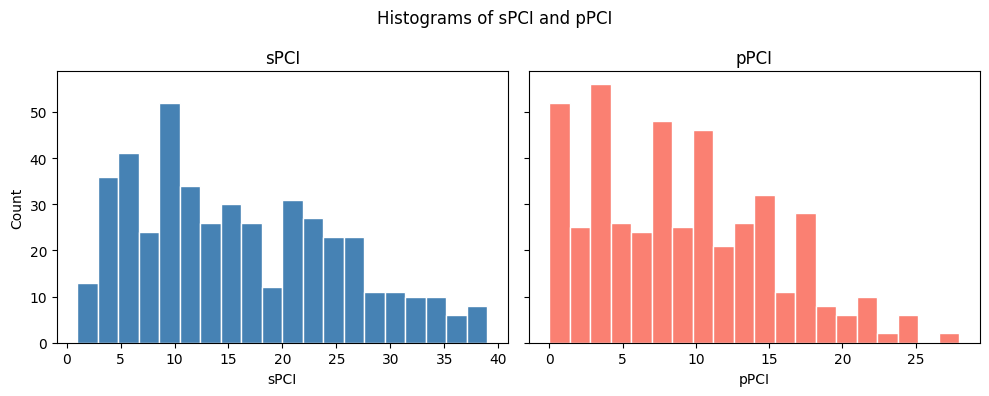

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

axes[0].hist(df['sPCI'].dropna(), bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('sPCI')
axes[0].set_xlabel('sPCI')
axes[0].set_ylabel('Count')

axes[1].hist(df['pPCI'].dropna(), bins=20, color='salmon', edgecolor='white')
axes[1].set_title('pPCI')
axes[1].set_xlabel('pPCI')

plt.suptitle('Histograms of sPCI and pPCI')
plt.tight_layout()
plt.savefig(PLOTS_PATH / "histograms_sPCI_pPCI.png", dpi=600)
plt.show()


In [9]:
from survival.agreement import paired_permutation_test, paired_permutation_test_median, paired_bootstrap_ci, sign_test, paired_bootstrap_ci_bca
from survival.agreement import bland_altman_analysis, intraclass_correlation, icc_bias_corrected, bland_altman_analysis_robust, bland_altman_regression_loa

In [10]:
# Median permutation test
stat_med, p_med = paired_permutation_test_median(sPCI, pPCI, random_state=42)
print("Median test:", stat_med, "p_value:", p_med)

# Bootstrap CI for median
ci_med = paired_bootstrap_ci(sPCI, pPCI, statistic="median", random_state=42)
ci_med_bca = paired_bootstrap_ci_bca(sPCI, pPCI, statistic="median", random_state=42)

print("Median CI:", np.round(ci_med,3))
print("Median BCa CI:", np.round(ci_med_bca,3))

Median test: 5.0 p_value: 4.999750012499375e-05
Median CI: [4. 6.]
Median BCa CI: [4. 5.]


In [11]:
stat, p_perm = paired_permutation_test(sPCI, pPCI, n_permutations=20000, random_state=42)
print("Permutation test:", stat, p_perm)

# Bootstrap CI for mean (optional)
ci_mean = paired_bootstrap_ci(sPCI, pPCI, statistic="mean", random_state=42)
ci_bca_mean = paired_bootstrap_ci_bca(sPCI, pPCI, statistic="mean", random_state=42)
print("Mean CI:", np.round(ci_mean,3))
print("Mean BCa CI:", np.round(ci_bca_mean,3))

Permutation test: 6.942731277533039 4.999750012499375e-05
Mean CI: [6.313 7.586]
Mean BCa CI: [6.325 7.599]


In [12]:
# Sign test
n_pos, n, p_sign = sign_test(sPCI, pPCI)
print("Sign test:", n_pos, "/", n, "p =", p_sign)

Sign test: 399 / 429 p = 1.9595350909587295e-83


In [13]:
# Inspect bootstrap distribution
boot_stats = []

rng = np.random.default_rng(42)
d = sPCI - pPCI
n = len(d)

for _ in range(20000):
    sample = d[rng.integers(0, n, n)]
    boot_stats.append(np.median(sample))

unique, counts = np.unique(boot_stats, return_counts=True)
print(dict(zip(unique, counts)))

{np.float64(4.0): np.int64(703), np.float64(4.5): np.int64(128), np.float64(5.0): np.int64(18345), np.float64(5.5): np.int64(139), np.float64(6.0): np.int64(680), np.float64(7.0): np.int64(5)}


=== Bland-Altman Results ===
Mean bias (sPCI - pPCI): 6.943
SD of differences:             6.861
Upper limit of agreement:      20.390
Lower limit of agreement:      -6.504


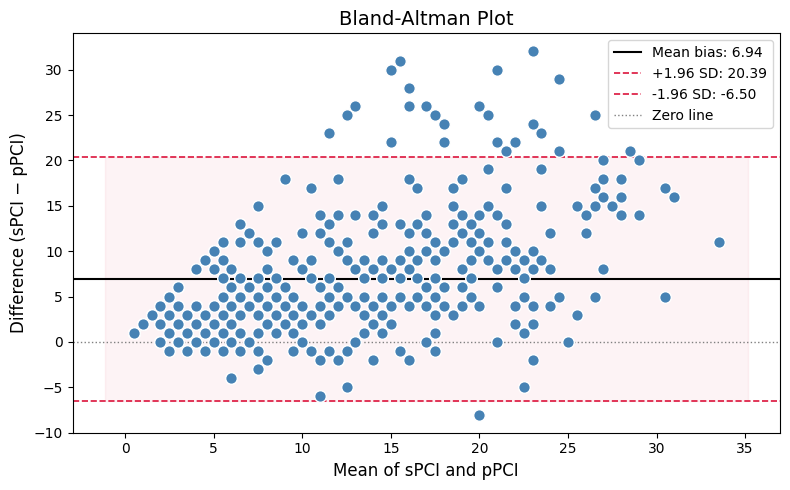

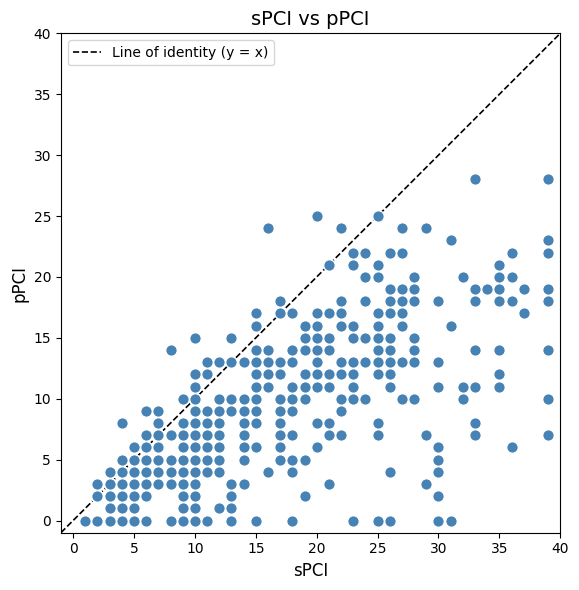

In [14]:
# Bland-Altman plot
result = bland_altman_analysis(sPCI, pPCI, plots_path=PLOTS_PATH)


In [15]:
#icc
icc = intraclass_correlation(sPCI, pPCI)
print(icc)

Type       ICC(A,1)
ICC        0.461483
CI95    [-0.0, 0.7]
pval            0.0
Name: 1, dtype: object


In [16]:
delta, icc_corr = icc_bias_corrected(sPCI, pPCI, method="median")

print("Bias removed:", delta)
print(icc_corr)

Bias removed: 5.0
       Type       ICC          CI95          pval
1  ICC(A,1)  0.616459  [0.54, 0.68]  7.736085e-53


In [17]:
robust_res = bland_altman_analysis_robust(sPCI, pPCI, plots_path=PLOTS_PATH)

=== Bland-Altman Results ===
  Methods:                sPCI - pPCI  (n=454)
  Mean bias:              6.943
  Median bias:            5.000
  SD of differences:      6.861
  Classical LoA:          [-6.504, 20.390]
  Robust LoA (quantile):  [-2.000, 25.000]
  Proportional bias:      slope=0.486, intercept=0.913, r=0.514 (p=6.119e-32)


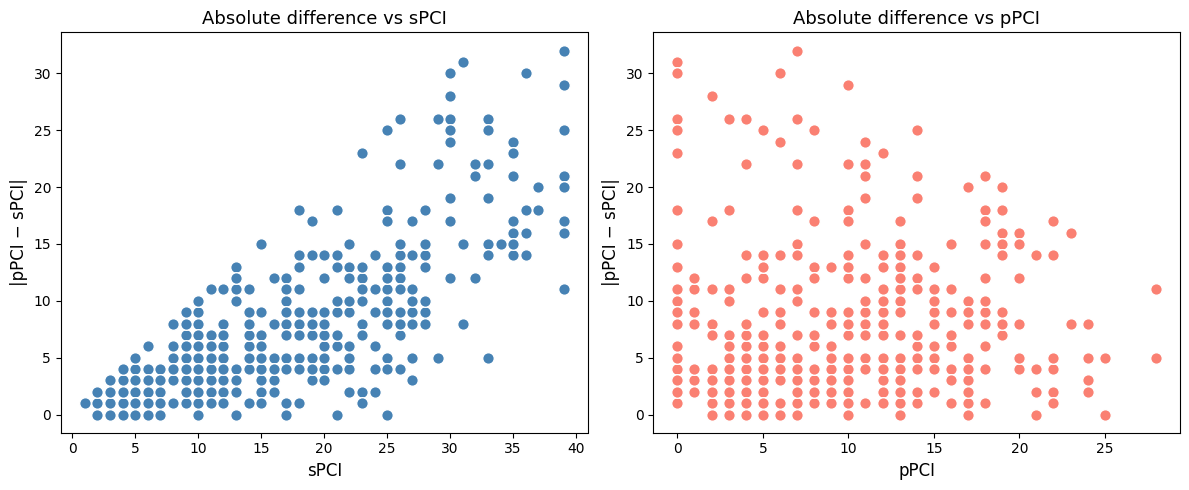

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

abs_diff = np.abs(pPCI - sPCI)

axes[0].scatter(sPCI, abs_diff, color="steelblue", edgecolors="white", s=70)
axes[0].set_xlabel("sPCI", fontsize=12)
axes[0].set_ylabel("|pPCI − sPCI|", fontsize=12)
axes[0].set_title("Absolute difference vs sPCI", fontsize=13)

axes[1].scatter(pPCI, abs_diff, color="salmon", edgecolors="white", s=70)
axes[1].set_xlabel("pPCI", fontsize=12)
axes[1].set_ylabel("|pPCI − sPCI|", fontsize=12)
axes[1].set_title("Absolute difference vs pPCI", fontsize=13)

plt.tight_layout()
plt.show()

In [19]:
# Regression-based LoA (Bland & Altman 1999) — accounts for proportional bias
reg_res = bland_altman_regression_loa(sPCI, pPCI, plots_path=PLOTS_PATH)

=== Bland-Altman: Regression-Based LoA ===
  n = 454
  Bias:              d = 0.913 + 0.486·mean  (r=0.514, p=6.119e-32)
  Heteroscedastic:   Yes  (|residuals| ~ mean: slope=0.1765, p=1.076e-11)

    mean     bias   LoA lower   LoA upper
       5     3.34       -3.81       10.49
      10     5.78       -3.54       15.09
      15     8.21       -3.28       19.69
      20    10.64       -3.01       24.29
      25    13.07       -2.75       28.89
